# Enterprise Explainable Forecasting Suite (SHAP Feature Attribution)

This notebook implements **Explainable Machine Learning Forecasting** using **SHAP (SHapley Additive exPlanations)** across all 8 pharmaceutical drug categories.

### 5 Core Business & Technical Objectives Satisfied:
1. **Explain Prediction Direction**: Quantify why the model predicts an increase or decrease in sales relative to the baseline demand anchor.
2. **Identify Top Feature Drivers**: Rank the most influential feature drivers (historical lags $t-1, t-7$, rolling statistics, Fourier annual seasonality, calendar day-of-week).
3. **Model Transparency & Interpretability**: Eliminate "black box" machine learning predictions using game-theoretic additive attribution.
4. **Decompose Domain Drivers**: Break down the relative contributions of **Historical Lags**, **Weekly & Annual Seasonality**, and **Time Regressors**.
5. **Support Trustworthy Decisions**: Provide clear, data-driven explanations for pharmacy procurement managers.


In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

OUTPUT_DIR = r'c:\Users\ranje\sales forcasting\explainable_forecasting'

# Load Global SHAP Summary
global_imp_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'explainable_forecasting_summary.csv'))

print("==========================================================================")
print("  GLOBAL TOP FEATURE DRIVER SUMMARY PER DRUG CATEGORY")
print("==========================================================================")
top_per_drug = global_imp_df.groupby('drug_category').first().reset_index()
display(top_per_drug[['drug_category', 'feature', 'feature_domain', 'mean_abs_shap']])


  GLOBAL TOP FEATURE DRIVER SUMMARY PER DRUG CATEGORY


,drug_category,feature,feature_domain,mean_abs_shap
0,M01AB,rolling_mean_28,Rolling Window Stat,0.053615
1,M01AE,sin_dayofweek,Weekly Seasonality,0.046028
2,N02BA,rolling_mean_28,Rolling Window Stat,0.148662
3,N02BE,rolling_mean_28,Rolling Window Stat,0.090330
4,N05B,dayofweek,Weekly Seasonality,0.061977
5,N05C,cos_dayofyear,Annual Seasonality,0.030567
6,R03,rolling_mean_28,Rolling Window Stat,0.205276
7,R06,rolling_mean_28,Rolling Window Stat,0.151698


In [2]:
# Load Daily Prediction Direction Attribution Breakdown
sample_attr_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'explainable_shap_breakdown.csv'))

print("==========================================================================")
print("  SAMPLE DAILY PREDICTION DIRECTION & SHAP DRIVER BREAKDOWN")
print("==========================================================================")
display(sample_attr_df.head(12))


  SAMPLE DAILY PREDICTION DIRECTION & SHAP DRIVER BREAKDOWN


,date,drug_category,actual_sales,predicted_sales,base_value_log,top_positive_driver,top_negative_driver,prediction_direction
0,2019-01-01,M01AB,0.00,3.08,1.6701,rolling_mean_7 (+0.072),cos_dayofyear (-0.174),DOWN (Below Base)
1,2019-01-02,M01AB,5.33,1.90,1.6701,rolling_std_7 (+0.051),cos_dayofyear (-0.232),DOWN (Below Base)
2,2019-01-03,M01AB,4.33,3.13,1.6701,rolling_std_7 (+0.065),lag_14 (-0.144),DOWN (Below Base)
3,2019-01-04,M01AB,7.00,4.54,1.6701,cos_dayofyear (+0.131),rolling_mean_14 (-0.154),UP (Above Base)
4,2019-01-05,M01AB,8.01,3.45,1.6701,sin_dayofweek (+0.060),rolling_mean_14 (-0.173),DOWN (Below Base)
5,2019-01-06,M01AB,8.33,2.89,1.6701,lag_14 (+0.047),cos_dayofyear (-0.173),DOWN (Below Base)
6,2019-01-07,M01AB,0.00,2.64,1.6701,lag_14 (+0.080),cos_dayofyear (-0.263),DOWN (Below Base)
7,2019-01-08,M01AB,4.34,3.13,1.6701,sin_dayofyear (+0.038),lag_14 (-0.097),DOWN (Below Base)
8,2019-01-09,M01AB,3.00,4.93,1.6701,rolling_mean_14 (+0.045),lag_14 (-0.023),UP (Above Base)
9,2019-01-10,M01AB,8.00,3.90,1.6701,sin_dayofyear (+0.041),lag_7 (-0.044),DOWN (Below Base)


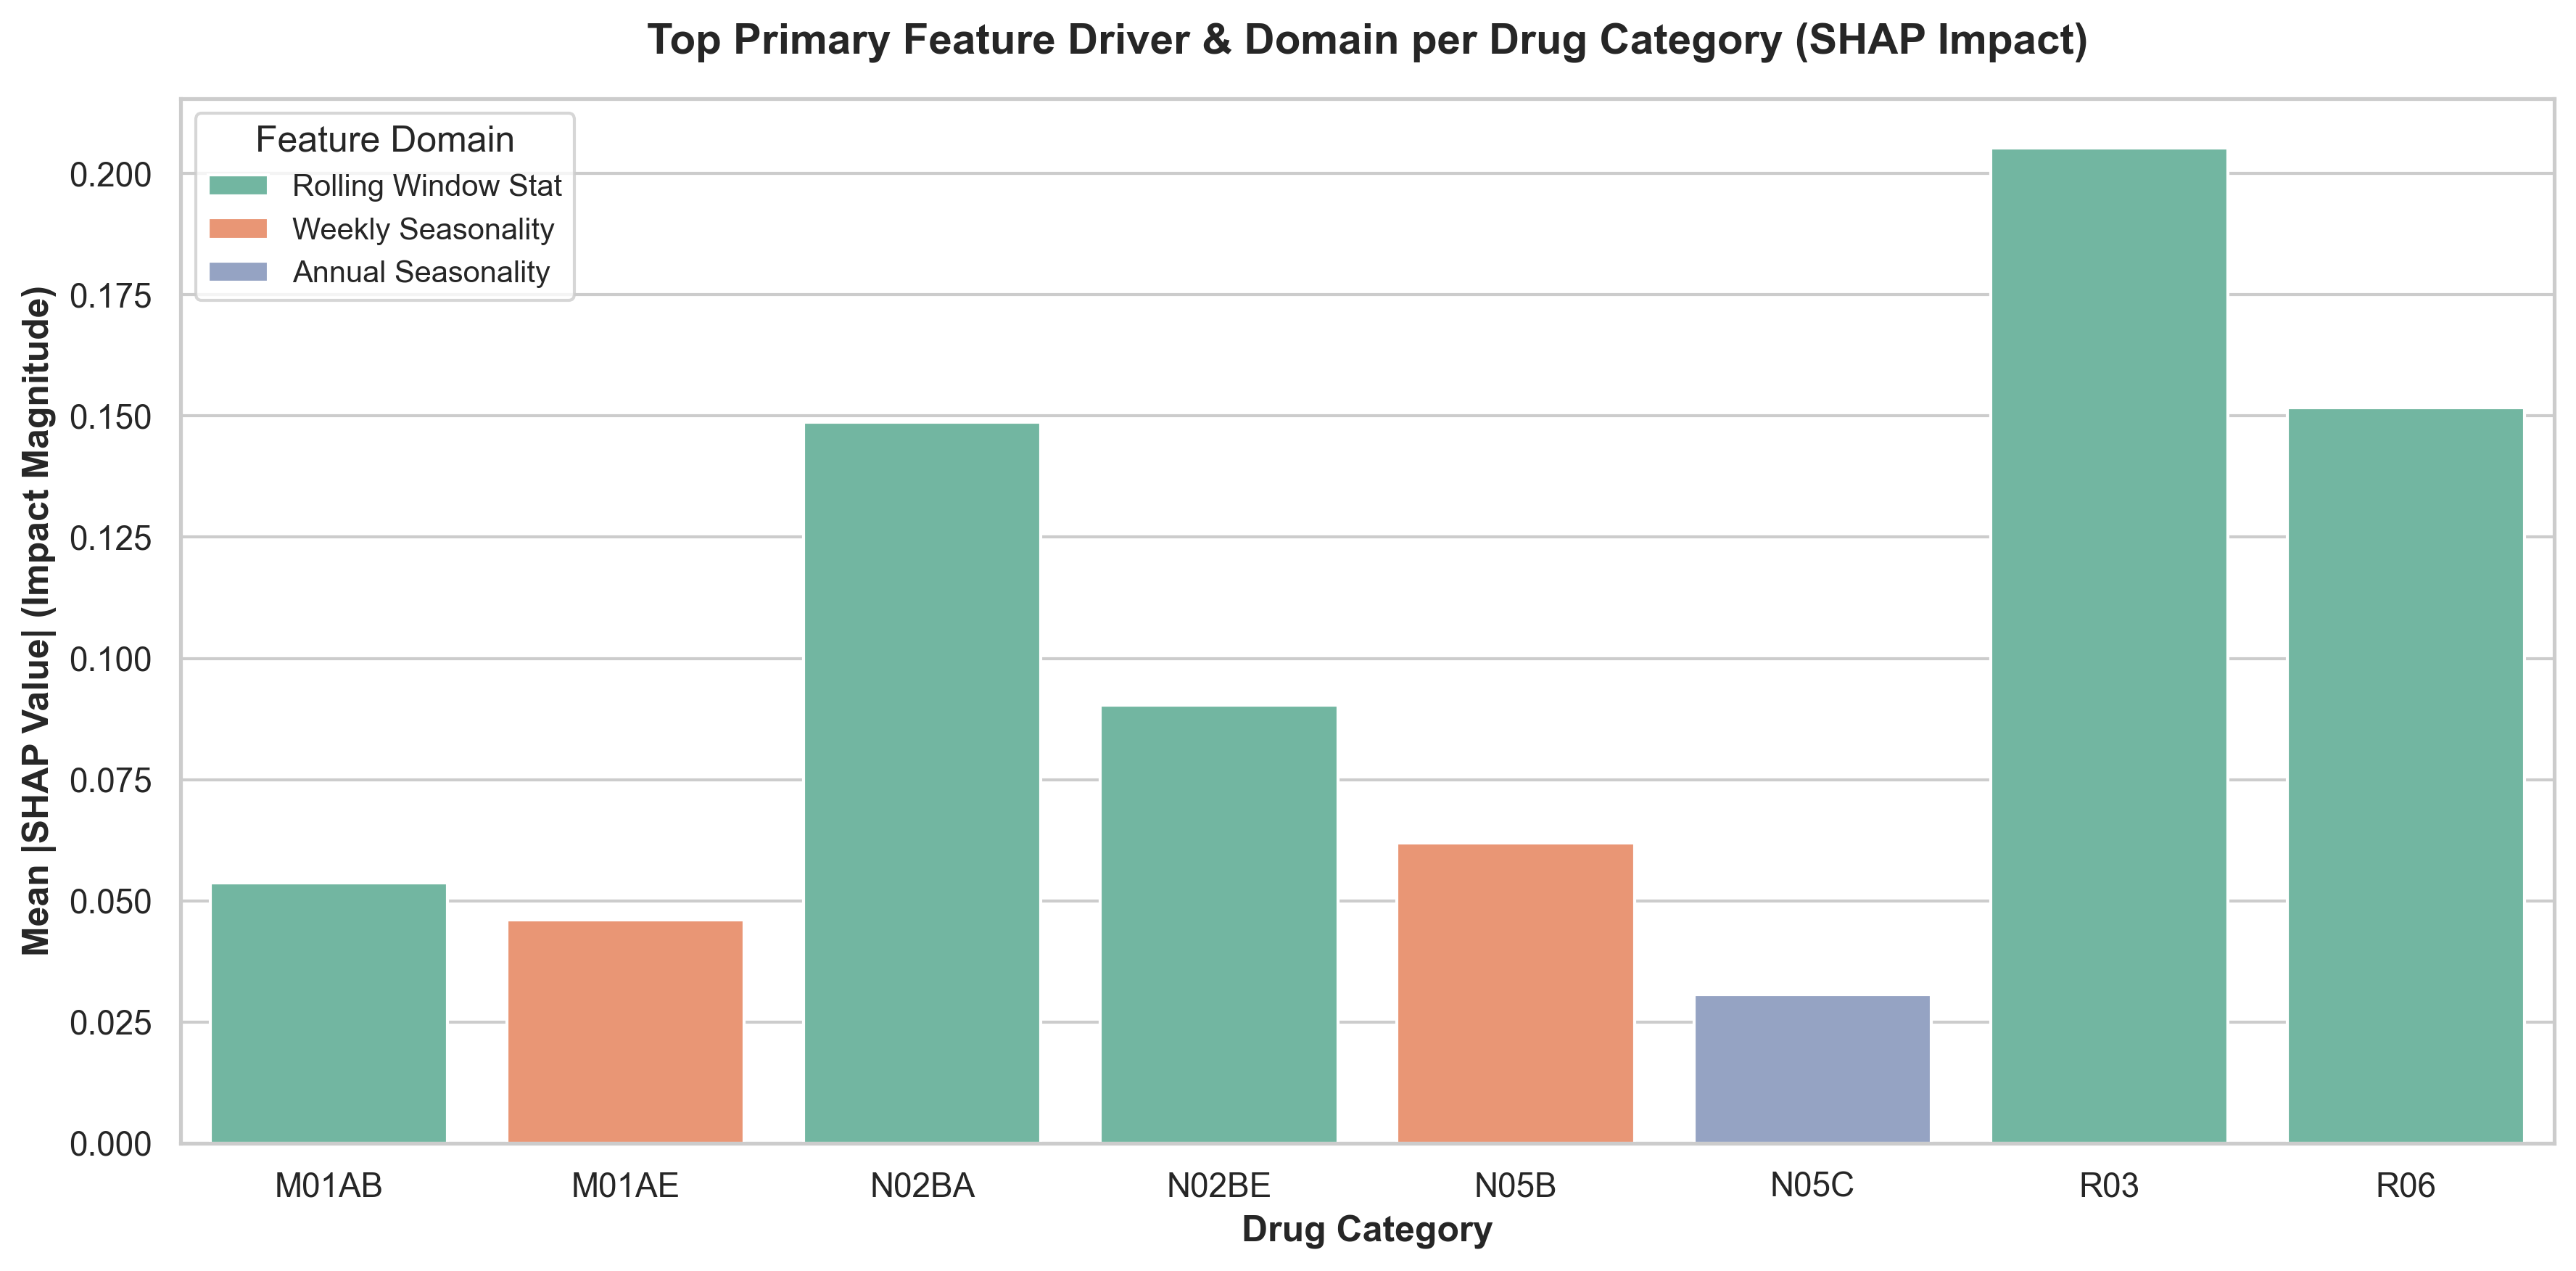

In [3]:
# Visualization: Top Feature Drivers across Portfolio
plt.figure(figsize=(12, 6), dpi=300)

sns.barplot(data=top_per_drug, x='drug_category', y='mean_abs_shap', hue='feature_domain', palette='Set2')
plt.title('Top Primary Feature Driver & Domain per Drug Category (SHAP Impact)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Drug Category', fontsize=12, fontweight='bold')
plt.ylabel('Mean |SHAP Value| (Impact Magnitude)', fontsize=12, fontweight='bold')
plt.legend(title='Feature Domain', fontsize=10)
plt.tight_layout()
plt.show()
